In [7]:
import os
import sys
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

os.chdir(r'D:\proyecto_eutrofizacion')
sys.path.insert(0, 'src')

from superpixels_slic import aplicar_slic, visualizar_superpixeles, exportar_superpixeles_csv
from water_masc1 import *
from water_masc2 import *

# ================================================================
# CARGAR DATOS
# ================================================================

BASE_PATH = r'D:\proyecto_eutrofizacion'
CSV_RIVER = Path(BASE_PATH) / 'data' / 'metadata' / 'river_water_index.csv'

df_river = pd.read_csv(CSV_RIVER)

# Filtra solo imágenes con máscaras
df_river_con_mask = df_river[df_river['segmentation_mask_path'].notna()].copy()

# Extrae nombre de archivo de la ruta
df_river_con_mask['filename'] = df_river_con_mask['filepath'].apply(
    lambda x: Path(x).name
)

print(f"✓ Cargadas {len(df_river_con_mask)} imágenes con máscaras")
print(f"✓ Años disponibles: {sorted(df_river_con_mask['group'].unique())}")

✓ Cargadas 7630 imágenes con máscaras
✓ Años disponibles: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


Aplicando SLIC (n_segments=300, compactness=10)...
✓ SLIC completado
  Superpíxeles creados: 52
  Tamaño promedio: 70788 píxeles/superpíxel


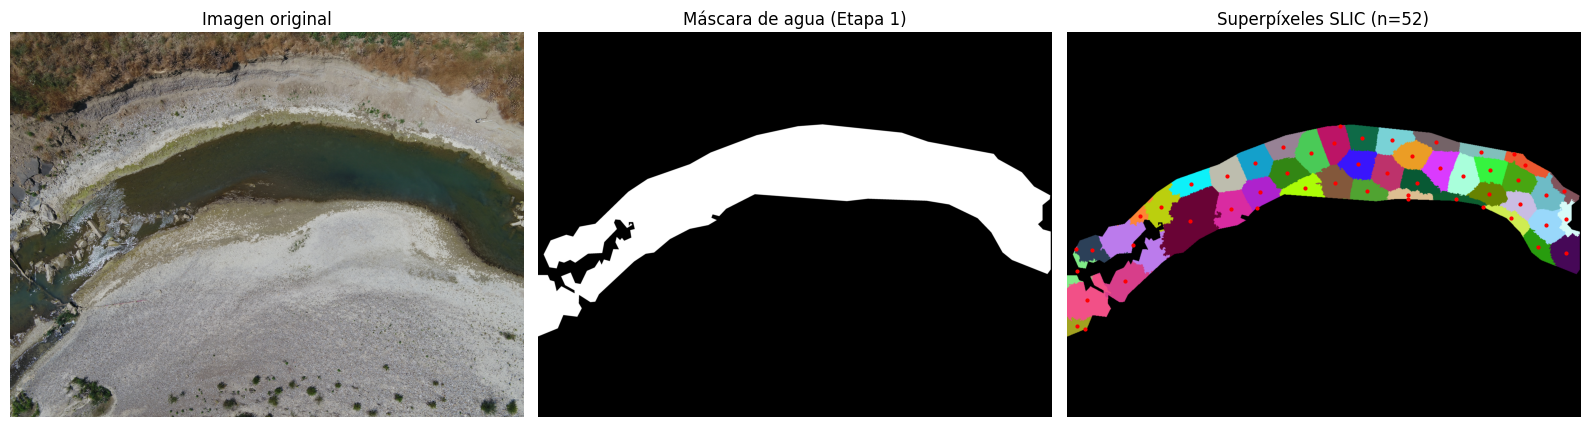

✓ Datos exportados: output/superpixeles_info.csv
  Total de superpíxeles: 52
   superpixel_id  n_pixeles  centroide_x  centroide_y      bgr_b       bgr_g  \
0             43        208  2807.038462   962.115385  71.990385   95.644231   
1             48      76704  3035.115353  1084.175845  43.019895   59.310805   
2             49      96320  2749.232890  1137.612957  42.480015   58.101246   
3             51      78976  3341.866288  1110.594003  43.453720   59.673192   
4             52     106688  2512.597181  1236.328434  43.172222   57.024192   
5             54      60880  3800.943890  1129.838502  39.913584   60.344826   
6             55      70128  2227.662902  1176.257016  38.275953   56.382144   
7             58         80  4598.300000  1247.100000  71.450000  102.125000   
8             60      86752  3551.355404  1265.857802  49.617496   61.320857   
9             61      52144  4261.250844  1230.377570  39.354077   60.543763   

        bgr_r      hsv_h      hsv_s       

In [6]:
# Cargar imagen y máscara (ejemplo con una imagen de RivAIrSet)
row = df_river_con_mask.iloc[0]  # Primera imagen
ruta_imagen = Path(BASE_PATH) / row['filepath']
ruta_mascara = Path(BASE_PATH) / row['segmentation_mask_path']

imagen_bgr = cv2.imread(str(ruta_imagen))
mascara_agua = cargar_mascara_desde_labeling(str(ruta_mascara), imagen_bgr.shape[0], imagen_bgr.shape[1])

# APLICAR ETAPA 2
resultado_slic = aplicar_slic(
    imagen_bgr,
    mascara_agua,
    n_segments=300,    # Ajusta según necesites (100-500)
    compactness=10     # Ajusta según necesites (1-20)
)

# Visualizar
fig, axes = visualizar_superpixeles(resultado_slic)
plt.show()

# Extraer información de cada superpíxel
imagen_hsv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV)
imagen_lab = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2LAB)

df_superpixeles = exportar_superpixeles_csv(
    resultado_slic,
    imagen_hsv,
    imagen_lab,
    'output/superpixeles_info.csv'
)

print(df_superpixeles.head(10))